# Adult Income Classification — Updated Project

This notebook predicts whether income is above `50K` using the Adult Census dataset.

## Main updates made
- Fixed missing-value handling: this dataset uses `?`, not `" ?"`.
- Replaced deprecated `sns.distplot()` with `sns.histplot()`.
- Converted accidental plain-text code cells into Markdown.
- Added `str.strip()` cleaning for target labels.
- Added stratified train/test split for class imbalance.
- Added reproducible `random_state` values.
- Used a modern preprocessing pipeline with imputing, scaling, and one-hot encoding.
- Added a clean model-comparison table and feature-importance chart.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import sklearn

print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("seaborn:", sns.__version__)

pandas: 2.2.3
scikit-learn: 1.8.0
seaborn: 0.13.2


## 1. Load and inspect the dataset

In [2]:
# Keep the CSV in the same folder as this notebook
data = pd.read_csv("adult.csv")

print("Shape:", data.shape)
display(data.head())
display(data.info())

Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


None

## 2. Clean missing values and target variable

In [3]:
# The Adult dataset uses '?' for missing categorical values
data = data.replace("?", np.nan)

# Remove extra spaces from text columns
for col in data.select_dtypes(include="object").columns:
    data[col] = data[col].str.strip()

# Encode target: >50K = 1, <=50K = 0
data["income"] = data["income"].map({">50K": 1, "<=50K": 0})

# Check missing values and target distribution
print("Missing values:")
display(data.isna().sum()[data.isna().sum() > 0])

print("\nTarget distribution:")
display(data["income"].value_counts(normalize=True).rename({0: "<=50K", 1: ">50K"}))

Missing values:


workclass         2799
occupation        2809
native-country     857
dtype: int64


Target distribution:


income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64

## 3. Exploratory Data Analysis

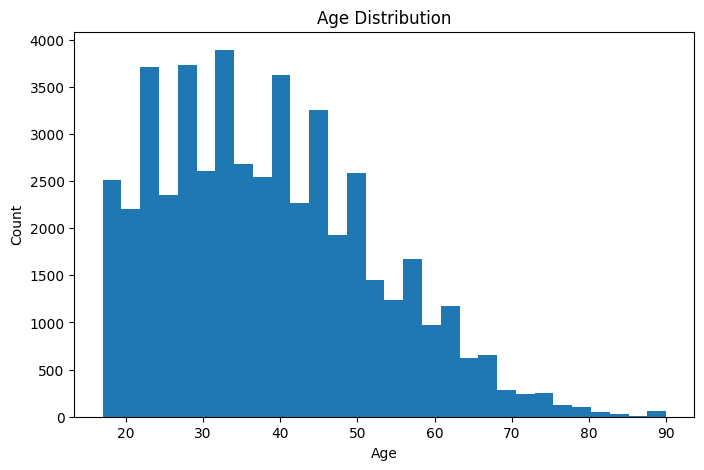

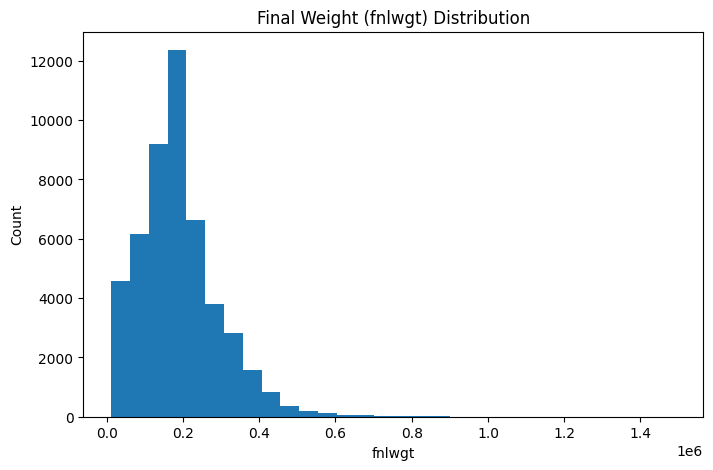

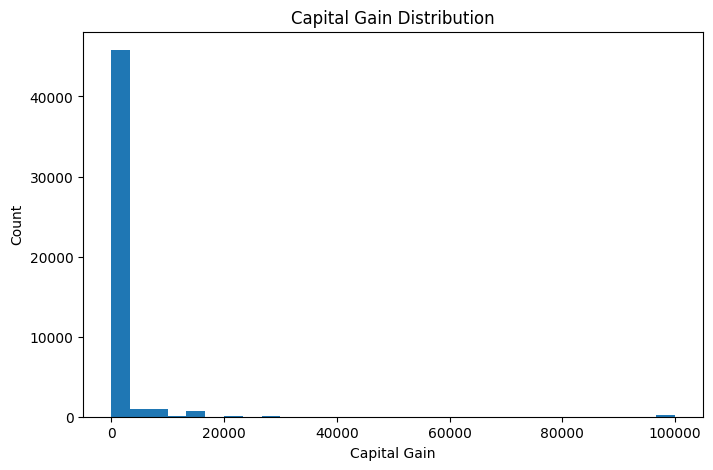

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data["age"].dropna(), bins=30)
ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data["fnlwgt"].dropna(), bins=30)
ax.set_title("Final Weight (fnlwgt) Distribution")
ax.set_xlabel("fnlwgt")
ax.set_ylabel("Count")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data["capital-gain"].dropna(), bins=30)
ax.set_title("Capital Gain Distribution")
ax.set_xlabel("Capital Gain")
ax.set_ylabel("Count")
plt.show()

## 4. Feature Engineering

The earlier notebook correctly noticed that **age**, **fnlwgt**, and **capital-gain** can be important.  
This updated version keeps the original numeric variables and also adds grouped versions of age and education for additional signal.


In [5]:
# Age groups
data["age_group"] = pd.cut(
    data["age"],
    bins=[0, 25, 32, 40, 50, np.inf],
    labels=["17-25", "26-32", "33-40", "41-50", "51+"]
)

# Education grouping
school_values = ["11th", "7th-8th", "10th", "5th-6th", "9th", "12th", "1st-4th", "Preschool"]
data["education_grouped"] = data["education"].replace({
    **{value: "School" for value in school_values},
    "Assoc-acdm": "Associate",
    "Assoc-voc": "Associate"
})

education_map = {
    "School": 1,
    "HS-grad": 2,
    "Some-college": 3,
    "Bachelors": 4,
    "Prof-school": 5,
    "Associate": 6,
    "Masters": 7,
    "Doctorate": 8
}

data["education_level"] = data["education_grouped"].map(education_map)

display(data[["age", "age_group", "education", "education_grouped", "education_level"]].head())

,age,age_group,education,education_grouped,education_level
0,25,17-25,11th,School,1
1,38,33-40,HS-grad,HS-grad,2
2,28,26-32,Assoc-acdm,Associate,6
3,44,41-50,Some-college,Some-college,3
4,18,17-25,Some-college,Some-college,3


## 5. Train/test split and preprocessing pipeline

In [6]:
X = data.drop(columns=["income"])
y = data["income"]

numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler())
        ]), numerical_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_cols)
    ],
    verbose_feature_names_out=False
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Numerical columns: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'education_level']
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'age_group', 'education_grouped']
Training set: (39073, 17)
Test set: (9769, 17)


## 6. Train and compare models

Two models are compared:
- Logistic Regression: simple baseline model.
- Random Forest: strong tree-based model that also provides feature importances.

A heavier Gradient Boosting model can also be added later, but this version is kept faster and easier to run for submission.


In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=75,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

results = []
trained_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    trained_pipelines[name] = pipeline

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.834886,0.617200,0.81651,0.703001
0,Logistic Regression,0.807452,0.564786,0.85201,0.679284


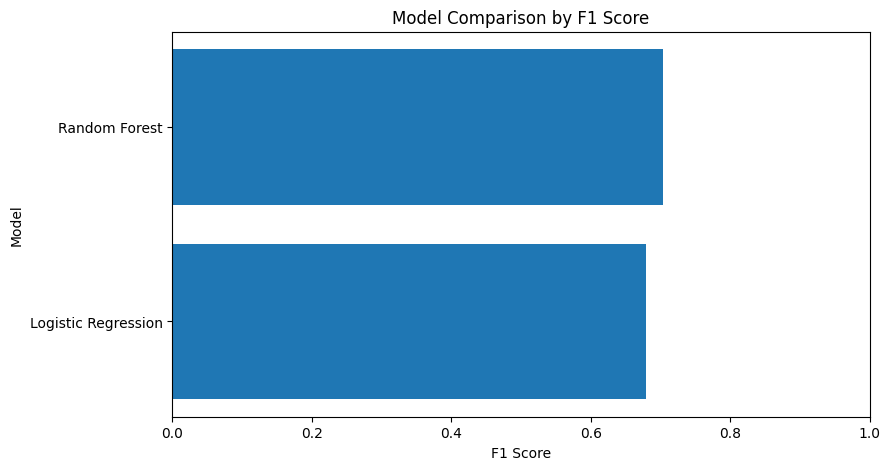

In [8]:
plot_df = results_df.sort_values("F1 Score")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["Model"], plot_df["F1 Score"])
ax.set_title("Model Comparison by F1 Score")
ax.set_xlabel("F1 Score")
ax.set_ylabel("Model")
ax.set_xlim(0, 1)
plt.show()

## 7. Best model evaluation

Best model based on F1 Score: Random Forest


              precision    recall  f1-score   support

       <=50K       0.94      0.84      0.89      7431
        >50K       0.62      0.82      0.70      2338

    accuracy                           0.83      9769
   macro avg       0.78      0.83      0.79      9769
weighted avg       0.86      0.83      0.84      9769



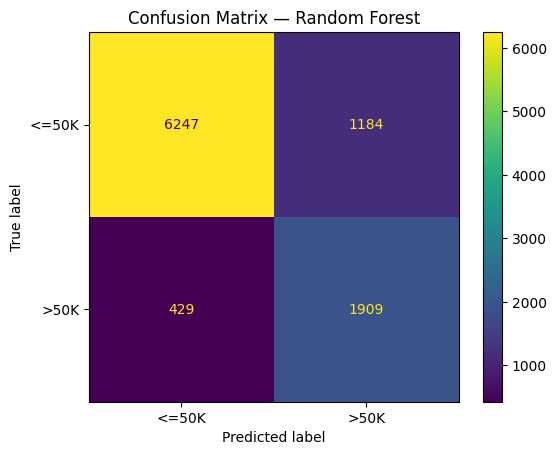

In [9]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]

print("Best model based on F1 Score:", best_model_name)

y_pred_best = best_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names=["<=50K", ">50K"]))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=["<=50K", ">50K"]
)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

## 8. Feature importance

,Feature,Importance
33,marital-status_Married-civ-spouse,0.135641
0,age,0.082227
3,capital-gain,0.074471
52,relationship_Husband,0.061076
35,marital-status_Never-married,0.059463
5,hours-per-week,0.055293
2,educational-num,0.051487
1,fnlwgt,0.051414
106,age_group_17-25,0.045257
6,education_level,0.044927


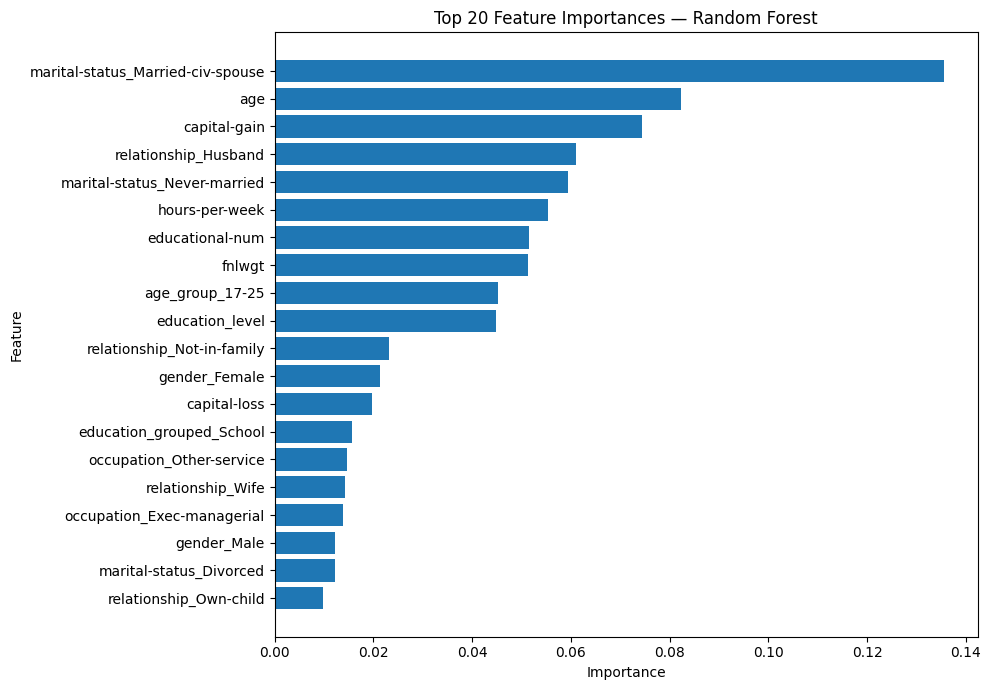

In [10]:
# Feature importance is available directly for tree-based models
tree_model_name = "Random Forest" if "Random Forest" in trained_pipelines else best_model_name
tree_pipeline = trained_pipelines[tree_model_name]

feature_names = tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = tree_pipeline.named_steps["model"].feature_importances_

feature_importances = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values(by="Importance", ascending=False)
    .head(20)
)

display(feature_importances)

plot_df = feature_importances.sort_values("Importance")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df["Feature"], plot_df["Importance"])
ax.set_title(f"Top 20 Feature Importances — {tree_model_name}")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## 9. Conclusion

The updated project uses a modern scikit-learn workflow and avoids deprecated plotting functions.  
The dataset has class imbalance, so F1 score, precision, and recall are more informative than accuracy alone.

The strongest features commonly include capital gain, education-related variables, age, hours per week, marital status, occupation, and relationship status.
